## Columns Description
Age : age [years]

anaemia : Decrease of red blood cells or hemoglobin (boolean)

creatinine_phosphokinase : Level of the CPK enzyme in the blood (mcg/L)

diabetes : If the patient has diabetes (boolean)

ejection_fraction : Percentage of blood leaving the heart at each contraction (percentage)

high_blood_pressure : If the patient has hypertension (boolean)

platelets : Platelets in the blood (kiloplatelets/mL)

serum_creatinine : Level of serum creatinine in the blood (mg/dL)

serum_sodium : Level of serum sodium in the blood (mEq/L)

sex : Woman or man (binary)

smoking : If the patient smokes or not (boolean)

time : Follow-up period (days)

DEATH_EVENT : If the patient deceased during the follow-up period (boolean)

In [92]:
# Core libraries used throughout the notebook
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

In [93]:
# Load the raw Heart Failure Clinical Records dataset (299 patients)
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [94]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [96]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


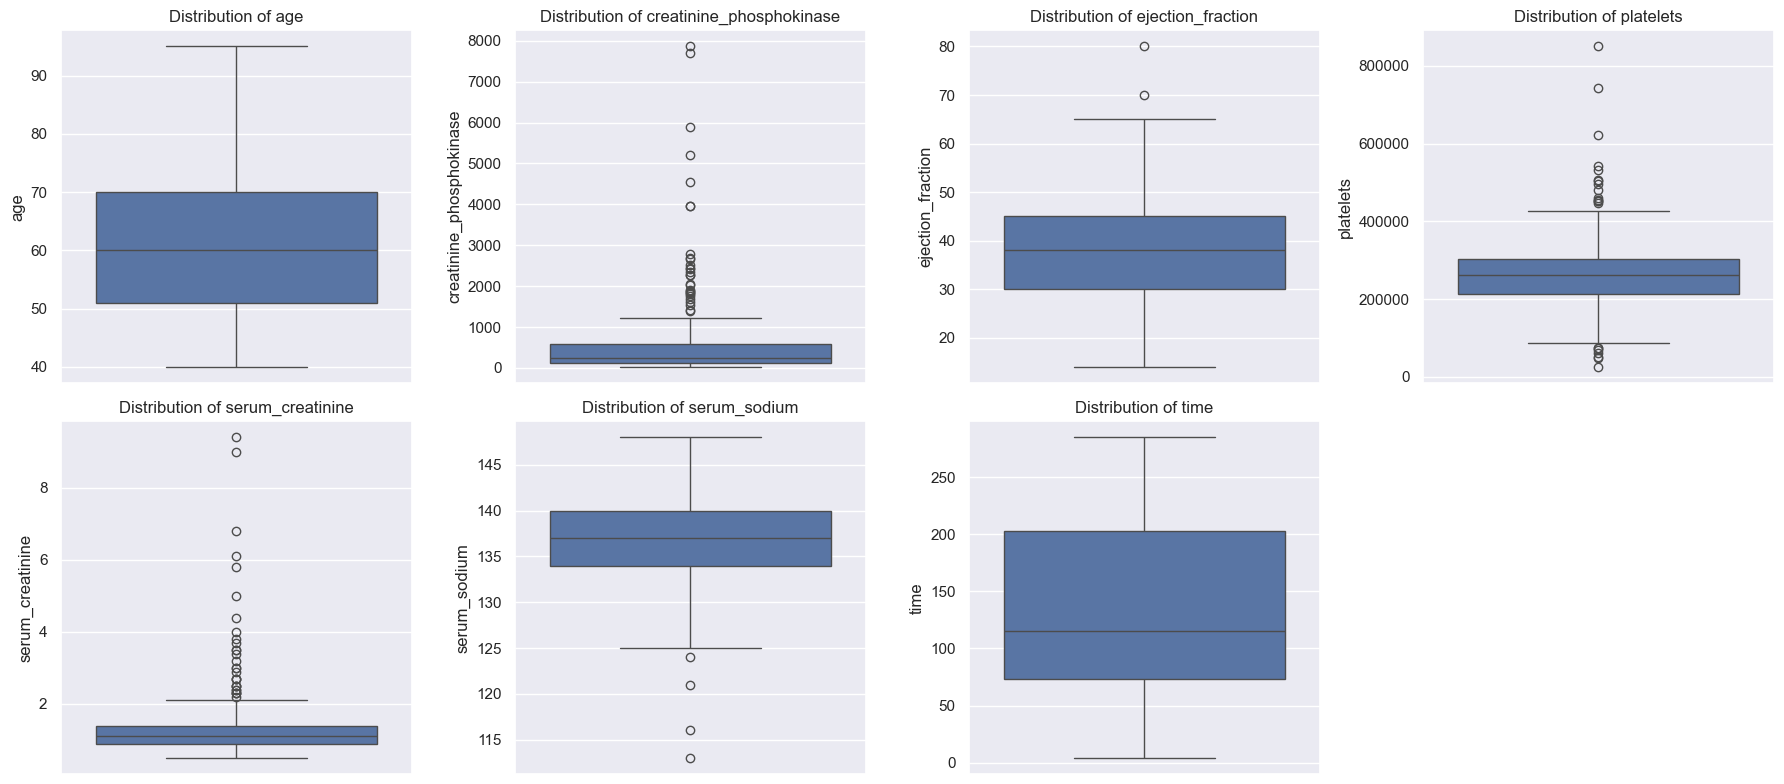

In [97]:
# Distribution of each continuous clinical feature, to spot skew/outliers before modeling
numerical_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                   'platelets', 'serum_creatinine', 'serum_sodium', 'time']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [98]:
df['creatinine_phosphokinase'].describe()
df[df['creatinine_phosphokinase'] > 1000].shape[0]

36

In [99]:
df[df['creatinine_phosphokinase'] > 1000]['DEATH_EVENT'].value_counts(normalize=True)

DEATH_EVENT
0    0.722222
1    0.277778
Name: proportion, dtype: float64

"Elevated CPK (>1000 mcg/L) affected ~12% of patients but did not show meaningfully higher mortality than the overall cohort — suggesting CPK alone is a weaker individual predictor of survival than its clinical severity might imply."

In [100]:
df[df['ejection_fraction'] > 65]

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
64,45.0,0,582,0,80,0,263358.03,1.18,137,0,0,63,0
217,54.0,1,427,0,70,1,151000.00,9.00,137,0,0,196,1


In [101]:
df[df['ejection_fraction'] < 20].shape[0]

5

In [102]:
df[(df['platelets'] < 150000) | (df['platelets'] > 450000)].shape[0]

40

In [103]:
df['serum_creatinine'].describe()

count    299.00000
mean       1.39388
std        1.03451
min        0.50000
25%        0.90000
50%        1.10000
75%        1.40000
max        9.40000
Name: serum_creatinine, dtype: float64

In [104]:
df[df['serum_creatinine'] > 6]

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
9,80.0,1,123,0,35,1,388000.00,9.4,133,1,1,10,1
52,60.0,0,3964,1,62,0,263358.03,6.8,146,0,0,43,1
131,60.0,1,1082,1,45,0,250000.00,6.1,131,1,0,107,0
217,54.0,1,427,0,70,1,151000.00,9.0,137,0,0,196,1


In [105]:
df['serum_sodium'].describe()

count    299.000000
mean     136.625418
std        4.412477
min      113.000000
25%      134.000000
50%      137.000000
75%      140.000000
max      148.000000
Name: serum_sodium, dtype: float64

In [106]:
df[df['serum_sodium']< 125].shape[0]

4

## Exploratory Data Analysis

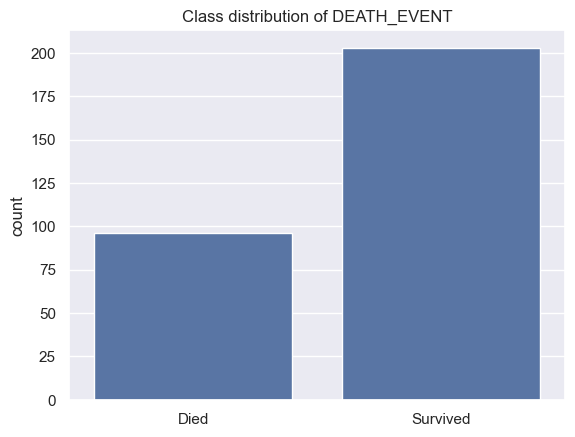

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64
DEATH_EVENT
0    67.892977
1    32.107023
Name: proportion, dtype: float64


In [107]:
sns.countplot(x=df['DEATH_EVENT'].map({0: 'Survived', 1: 'Died'}))
plt.title('Class distribution of DEATH_EVENT')
plt.xlabel('')
plt.show()

print(df['DEATH_EVENT'].value_counts())
print(df['DEATH_EVENT'].value_counts(normalize=True) * 100)

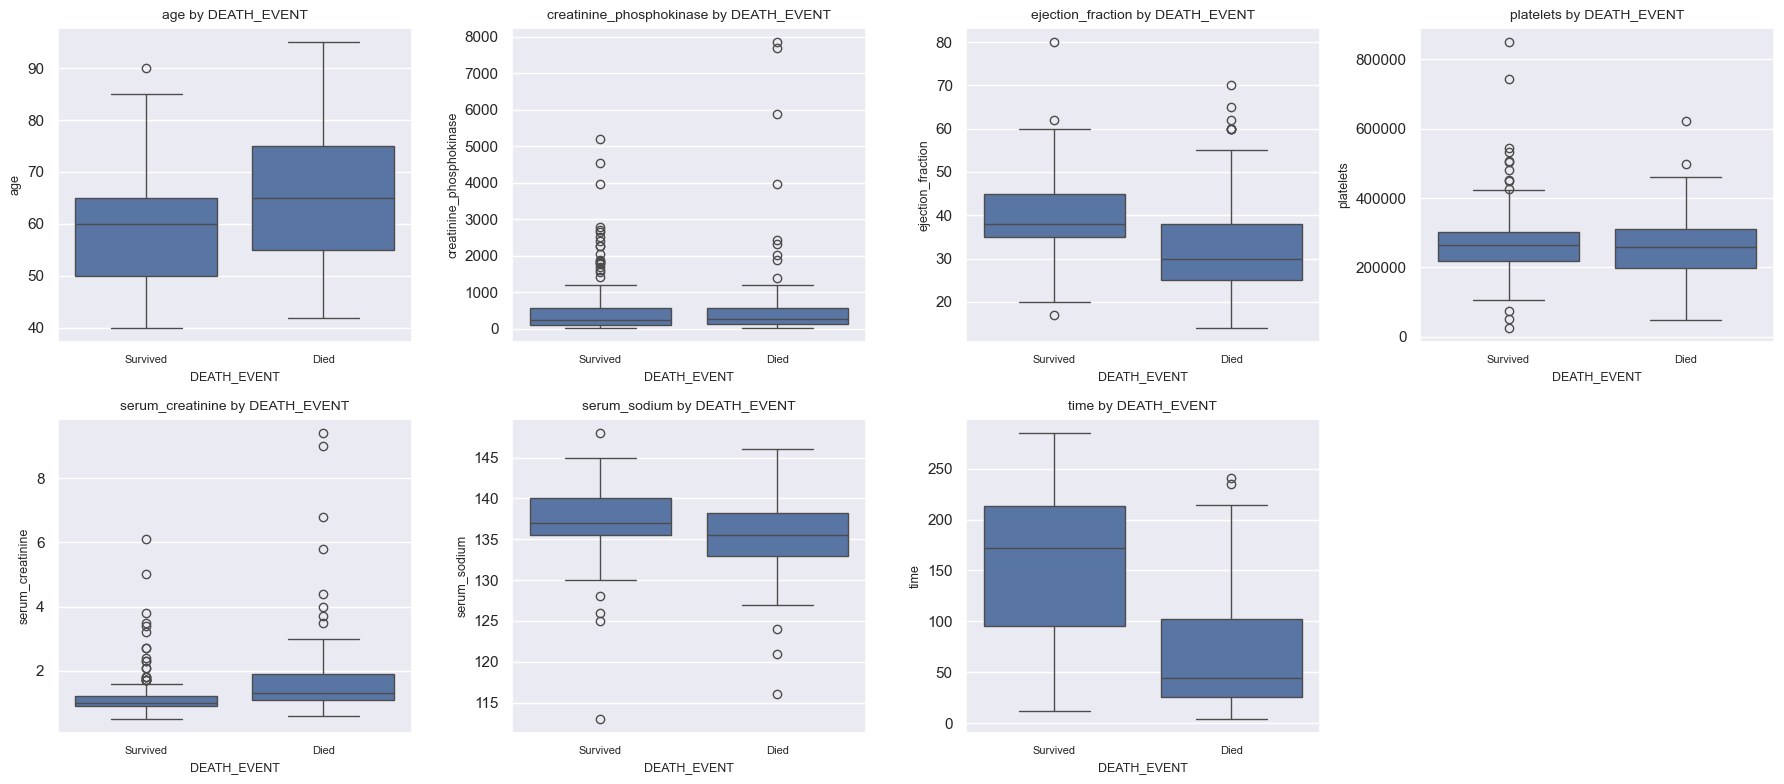

In [108]:
numerical_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 
                   'platelets', 'serum_creatinine', 'serum_sodium', 'time']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='DEATH_EVENT', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by DEATH_EVENT',fontsize = 10)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Survived', 'Died'], fontsize=8) 
    axes[i].set_xlabel('DEATH_EVENT', fontsize=9)
    axes[i].set_ylabel(col, fontsize=9)


for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

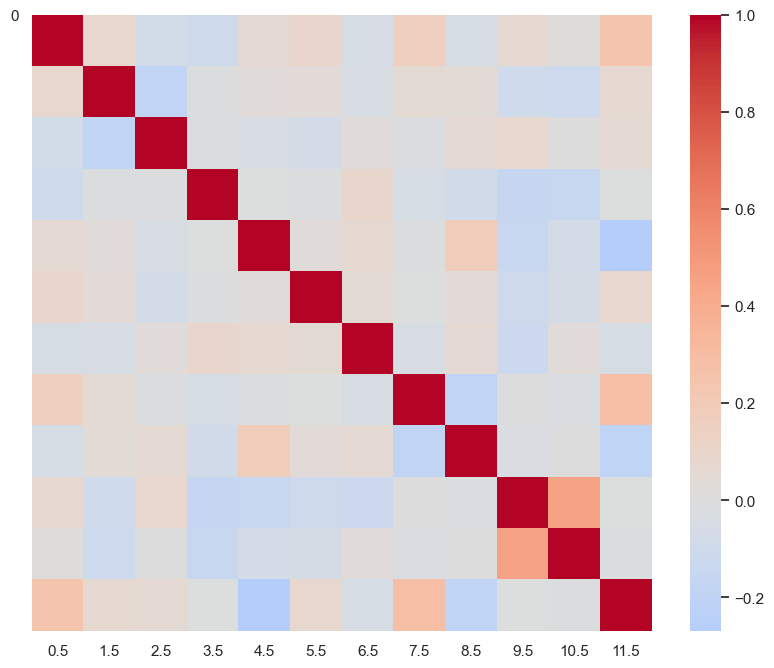

In [109]:
corr_cols = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 
             'ejection_fraction', 'high_blood_pressure', 'platelets', 
             'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'DEATH_EVENT']

plt.figure(figsize=(10, 8))
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 8})
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()

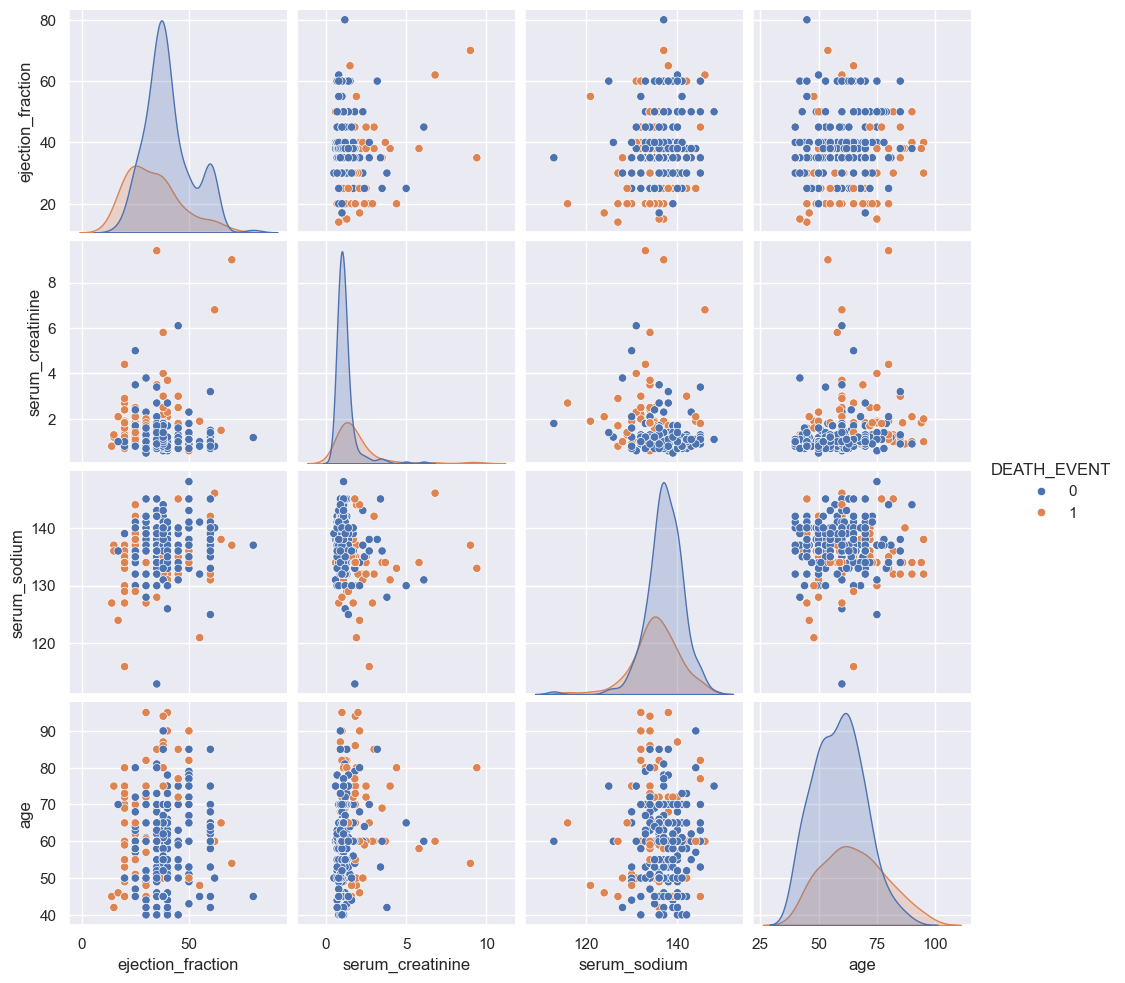

In [ ]:
sns.pairplot(df, hue='DEATH_EVENT', diag_kind='kde',
             vars=['ejection_fraction', 'serum_creatinine', 'serum_sodium', 'age'])
plt.show()

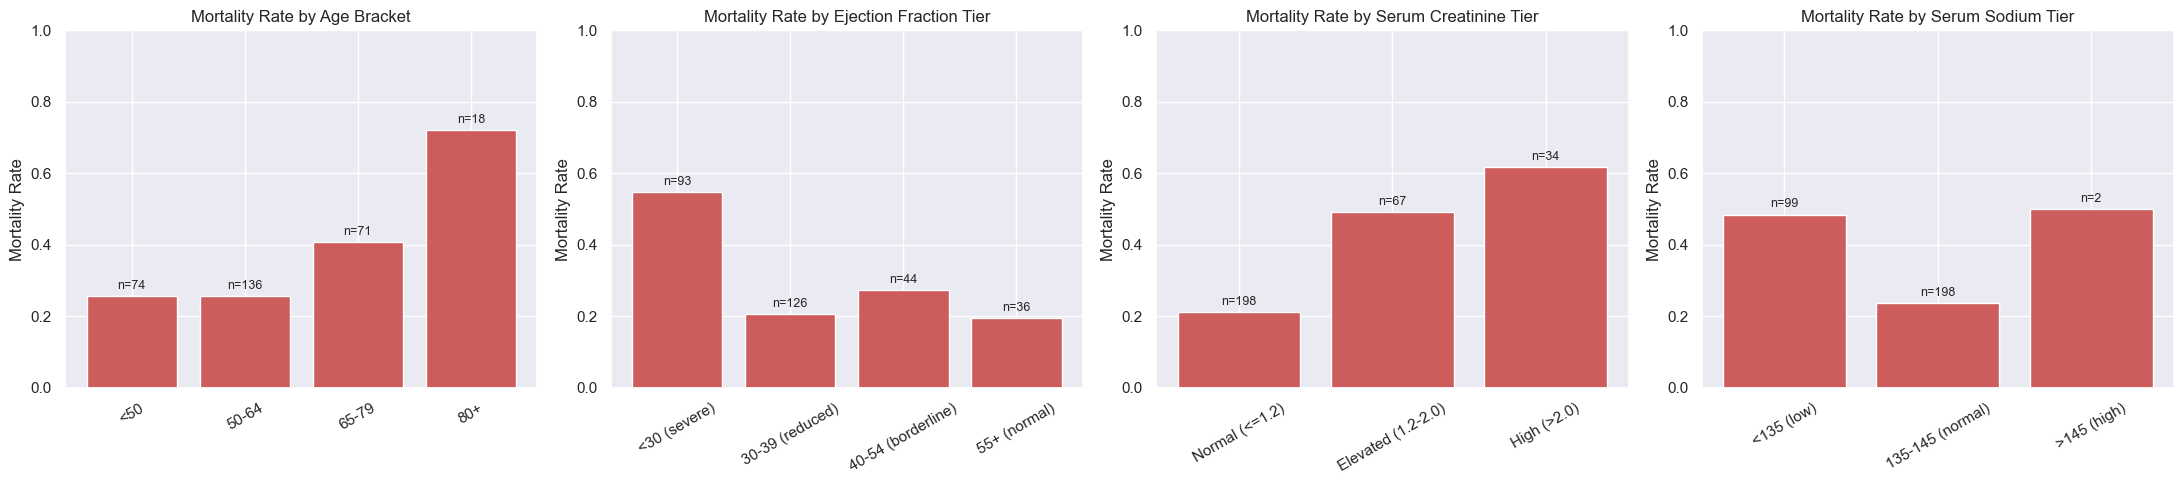


=== Age Bracket ===
             mortality_rate  n_patients
age_bracket                            
<50                0.256757          74
50-64              0.257353         136
65-79              0.408451          71
80+                0.722222          18

=== Ejection Fraction Tier ===
                    mortality_rate  n_patients
ef_tier                                       
<30 (severe)              0.548387          93
30-39 (reduced)           0.206349         126
40-54 (borderline)        0.272727          44
55+ (normal)              0.194444          36

=== Serum Creatinine Tier ===
                    mortality_rate  n_patients
creatinine_tier                               
Normal (<=1.2)            0.212121         198
Elevated (1.2-2.0)        0.492537          67
High (>2.0)               0.617647          34

=== Serum Sodium Tier ===
                  mortality_rate  n_patients
sodium_tier                                 
<135 (low)              0.484848          

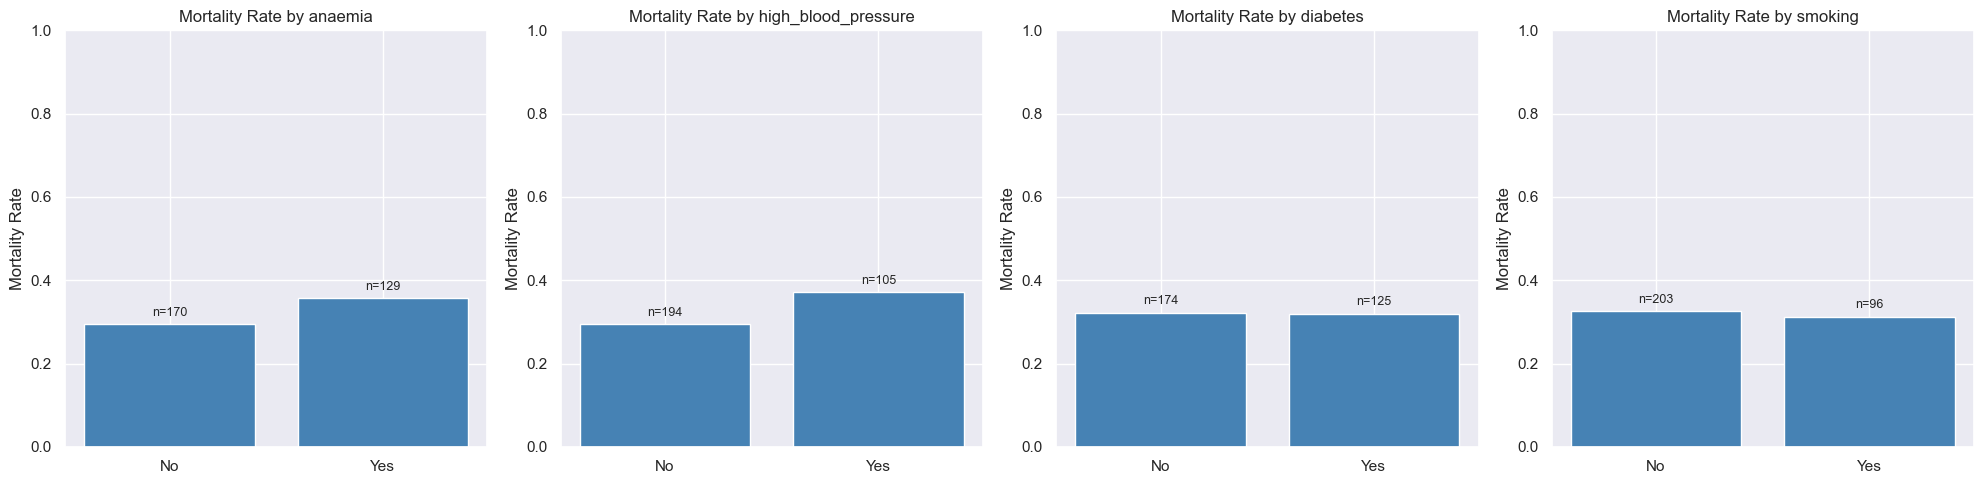


=== anaemia ===
         mortality_rate  n_patients
anaemia                            
0              0.294118         170
1              0.356589         129

=== high_blood_pressure ===
                     mortality_rate  n_patients
high_blood_pressure                            
0                          0.293814         194
1                          0.371429         105

=== diabetes ===
          mortality_rate  n_patients
diabetes                            
0               0.321839         174
1               0.320000         125

=== smoking ===
         mortality_rate  n_patients
smoking                            
0              0.325123         203
1              0.312500          96


In [ ]:
# --- Mortality rate by clinical risk-factor tiers ---
# Bins use standard clinical reference ranges rather than arbitrary quartiles.
# These columns (age_bracket, ef_tier, creatinine_tier) are reused later in the
# notebook, including in the Kaplan-Meier section further down.

# Age brackets
age_bins = [0, 50, 65, 80, 150]
age_labels = ['<50', '50-64', '65-79', '80+']
df['age_bracket'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Ejection fraction tiers: <30 severely reduced, 30-40 reduced, 40-55 borderline, 55+ normal
ef_bins = [0, 30, 40, 55, 100]
ef_labels = ['<30 (severe)', '30-39 (reduced)', '40-54 (borderline)', '55+ (normal)']
df['ef_tier'] = pd.cut(df['ejection_fraction'], bins=ef_bins, labels=ef_labels)

# Serum creatinine tiers: normal ~0.6-1.2 mg/dL, elevated indicates worsening kidney function
sc_bins = [0, 1.2, 2.0, 20]
sc_labels = ['Normal (<=1.2)', 'Elevated (1.2-2.0)', 'High (>2.0)']
df['creatinine_tier'] = pd.cut(df['serum_creatinine'], bins=sc_bins, labels=sc_labels)

sodium_bins = [0, 135, 145, 200]
sodium_labels = ['<135 (low)', '135-145 (normal)', '>145 (high)']
df['sodium_tier'] = pd.cut(df['serum_sodium'], bins=sodium_bins, labels=sodium_labels)

tiers_extended = {
    'Age Bracket': 'age_bracket',
    'Ejection Fraction Tier': 'ef_tier',
    'Serum Creatinine Tier': 'creatinine_tier',
    'Serum Sodium Tier': 'sodium_tier'
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (title, col) in zip(axes, tiers_extended.items()):
    mortality_by_tier = df.groupby(col, observed=True)['DEATH_EVENT'].mean().sort_index()
    counts_by_tier = df.groupby(col, observed=True).size()

    bars = ax.bar(mortality_by_tier.index.astype(str), mortality_by_tier.values, color='indianred')
    ax.set_title(f'Mortality Rate by {title}')
    ax.set_ylabel('Mortality Rate')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)

    # Annotate with n= sample size -- some tiers are small given only 299 patients total
    for bar, n in zip(bars, counts_by_tier.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'n={n}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

for title, col in tiers_extended.items():
    print(f"\n=== {title} ===")
    print(df.groupby(col, observed=True)['DEATH_EVENT'].agg(['mean', 'count']).rename(
        columns={'mean': 'mortality_rate', 'count': 'n_patients'}))


# --- Mortality rate by binary comorbidities ---
# These are already 0/1, so no binning needed — just compare "has condition" vs "doesn't"
binary_risk_factors = ['anaemia', 'high_blood_pressure', 'diabetes', 'smoking']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, col in zip(axes, binary_risk_factors):
    mortality_by_status = df.groupby(col, observed=True)['DEATH_EVENT'].mean()
    counts_by_status = df.groupby(col, observed=True).size()

    labels = ['No', 'Yes']
    bars = ax.bar(labels, mortality_by_status.values, color='steelblue')
    ax.set_title(f'Mortality Rate by {col}')
    ax.set_ylabel('Mortality Rate')
    ax.set_ylim(0, 1)

    for bar, n in zip(bars, counts_by_status.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'n={n}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

for col in binary_risk_factors:
    print(f"\n=== {col} ===")
    print(df.groupby(col, observed=True)['DEATH_EVENT'].agg(['mean', 'count']).rename(
        columns={'mean': 'mortality_rate', 'count': 'n_patients'}))

## Feature Relevance Check

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF checks relationships AMONG features only (never the target DEATH_EVENT),
# so computing it on the full dataset does not leak outcome information the way
# a target-aware feature-selection test would -- this is safe as a data-description step.
feature_cols = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
                 'ejection_fraction', 'high_blood_pressure', 'platelets',
                 'serum_creatinine', 'serum_sodium', 'sex', 'smoking']

X_vif = add_constant(df[feature_cols])

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data['Feature'] != 'const']
print(vif_data.sort_values('VIF', ascending=False))

                     Feature       VIF
10                       sex  1.337709
11                   smoking  1.283023
9               serum_sodium  1.096363
8           serum_creatinine  1.069243
1                        age  1.068365
2                    anaemia  1.066476
5          ejection_fraction  1.065725
4                   diabetes  1.064280
3   creatinine_phosphokinase  1.060983
7                  platelets  1.045777
6        high_blood_pressure  1.029255


No individual clinical feature strongly predicts survival on its own (max correlation with DEATH_EVENT: 0.29), and no features are redundant with each other (max VIF: 1.34). This means predictive power in this dataset comes from combining multiple weak-to-moderate signals, not leaning on one dominant or a cluster of correlated features — making it a genuinely fair testing ground for comparing how differently-shaped models (linear, polynomial, kernel-based, distance-based) combine that signal

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif

X = df[feature_cols]
y = df['DEATH_EVENT']

# Split FIRST, so feature selection only ever sees training data --
# this avoids leaking validation/test information into which features get
# treated as "significant" before any model exists.
#
# This is the ONE split used for every model in this notebook (Logistic
# Regression, Polynomial, KNN, SVC) -- later cells reuse X_train/X_val/X_test
# rather than re-splitting, so every model is trained/evaluated on the same patients.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, stratify=y_temp, random_state=42
)

# ANOVA F-test on the training split only
f_scores, p_values = f_classif(X_train, y_train)

anova_results = pd.DataFrame({
    'Feature': feature_cols,
    'F-score': f_scores,
    'p-value': p_values
}).sort_values('F-score', ascending=False)

print(anova_results)
print(f"\nTrain: {X_train.shape[0]} rows | Validation: {X_val.shape[0]} rows | Test: {X_test.shape[0]} rows")

                     Feature    F-score   p-value
7           serum_creatinine  20.054190  0.000014
4          ejection_fraction  18.351779  0.000031
8               serum_sodium   8.495956  0.004054
0                        age   2.774338  0.097684
2   creatinine_phosphokinase   1.747647  0.188003
1                    anaemia   1.538758  0.216564
5        high_blood_pressure   1.528386  0.218112
9                        sex   0.512557  0.475046
10                   smoking   0.433950  0.510975
3                   diabetes   0.318620  0.573205
6                  platelets   0.004735  0.945223

Train: 167 rows | Validation: 42 rows | Test: 90 rows


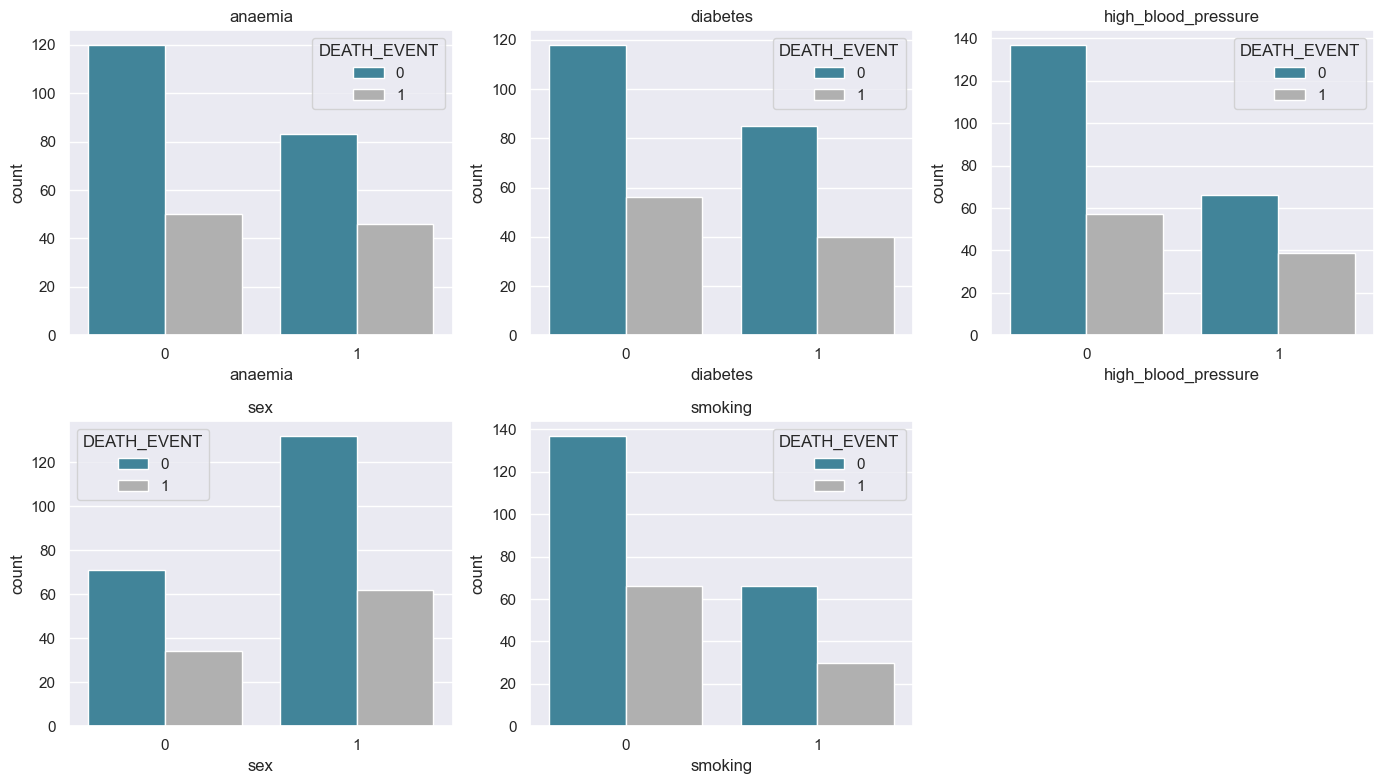

In [ ]:
# Raw survival/death counts per binary risk factor (complements the mortality-RATE
# bars in the tiered EDA above, which normalize for group size)
binary_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(binary_features):
    sns.countplot(data=df, x=col, hue='DEATH_EVENT', 
                   palette=["#328ba8", "#b0b0b0"], ax=axes[i])
    axes[i].set_title(col)

for j in range(len(binary_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Logistic Regression

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

features_significant = ['serum_creatinine', 'ejection_fraction', 'age', 'serum_sodium']

# X_train / X_val / X_test already exist from the split performed during the
# ANOVA step above (Feature Relevance Check section) -- reused here rather
# than re-splitting, so every model in this notebook trains/evaluates on the
# exact same patients.

# Subset the significant features from that same split
X_train_sig = X_train[features_significant]
X_val_sig = X_val[features_significant]
X_test_sig = X_test[features_significant]

# --- Scale: full feature set ---
scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train)
X_val_full_scaled = scaler_full.transform(X_val)
X_test_full_scaled = scaler_full.transform(X_test)

# --- Scale: significant feature set ---
scaler_sig = StandardScaler()
X_train_sig_scaled = scaler_sig.fit_transform(X_train_sig)
X_val_sig_scaled = scaler_sig.transform(X_val_sig)
X_test_sig_scaled = scaler_sig.transform(X_test_sig)

print(f"Train: {X_train.shape[0]} rows | Validation: {X_val.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 167 rows | Validation: 42 rows | Test: 90 rows


In [ ]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'class_weight': [None, 'balanced'],
}

# --- Significant features (4) ---
grid_log_sig = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_log_sig.fit(X_train_sig_scaled, y_train)
print("=== Logistic Regression (4 significant features) ===")
print(f"Best params: {grid_log_sig.best_params_}")
print(f"Best Recall (CV): {grid_log_sig.best_score_:.4f}")
best_log_sig = grid_log_sig.best_estimator_

# --- Full features (11) ---
grid_log_full = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_log_full.fit(X_train_full_scaled, y_train)
print("\n=== Logistic Regression (11 full features) ===")
print(f"Best params: {grid_log_full.best_params_}")
print(f"Best Recall (CV): {grid_log_full.best_score_:.4f}")
best_log_full = grid_log_full.best_estimator_

=== Logistic Regression (4 significant features) ===
Best params: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2'}
Best Recall (CV): 0.7000

=== Logistic Regression (11 full features) ===
Best params: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2'}
Best Recall (CV): 0.6836


=== 4 significant features (default threshold) ===
              precision    recall  f1-score   support

           0       0.82      0.79      0.81        29
           1       0.57      0.62      0.59        13

    accuracy                           0.74        42
   macro avg       0.70      0.70      0.70        42
weighted avg       0.74      0.74      0.74        42


=== 11 full features (default threshold) ===
              precision    recall  f1-score   support

           0       0.83      0.66      0.73        29
           1       0.47      0.69      0.56        13

    accuracy                           0.67        42
   macro avg       0.65      0.67      0.65        42
weighted avg       0.72      0.67      0.68        42



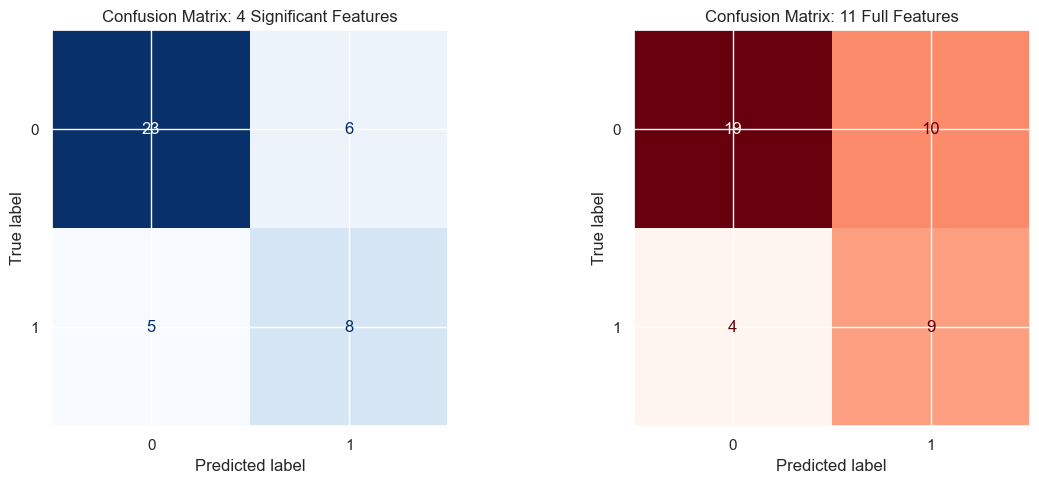

In [ ]:

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# --- 1. Evaluate 4 Significant Features ---
y_val_pred_sig = best_log_sig.predict(X_val_sig_scaled)
print("=== 4 significant features (default threshold) ===")
print(classification_report(y_val, y_val_pred_sig))

# --- 2. Evaluate 11 Full Features ---
y_val_pred_full = best_log_full.predict(X_val_full_scaled)
print("\n=== 11 full features (default threshold) ===")
print(classification_report(y_val, y_val_pred_full))

# --- 3. Plotting the Confusion Matrices Side-by-Side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot for 4 features
ConfusionMatrixDisplay.from_predictions(
    y_val, 
    y_val_pred_sig, 
    ax=axes[0], 
    cmap='Blues',      # Adds a nice blue color gradient
    colorbar=False     # Hides the color scale bar to save space
)
axes[0].set_title('Confusion Matrix: 4 Significant Features')

# Plot for 11 features
ConfusionMatrixDisplay.from_predictions(
    y_val, 
    y_val_pred_full, 
    ax=axes[1], 
    cmap='Reds',       # Using a different color for easy distinction
    colorbar=False
)
axes[1].set_title('Confusion Matrix: 11 Full Features')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import recall_score

val_recall_class1 = recall_score(y_val, y_val_pred_sig, pos_label=1)
print(f"Validation Recall (class 1, died): {val_recall_class1:.4f}")
print(f"CV Recall (class 1, died): {grid_log_sig.best_score_:.4f}")

Validation Recall (class 1, died): 0.6154
CV Recall (class 1, died): 0.7000


In [ ]:
val_recall_full = recall_score(y_val, y_val_pred_full, pos_label=1)
print(f"Validation Recall (class 1, died) - full features: {val_recall_full:.4f}")
print(f"CV Recall (class 1, died) - full features: {grid_log_full.best_score_:.4f}")

Validation Recall (class 1, died) - full features: 0.6923
CV Recall (class 1, died) - full features: 0.6836


## Polynomial Features


In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# 1. Added StandardScaler to the Pipeline
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scaler', StandardScaler()),
    ('log', LogisticRegression(max_iter=1000))
])

param_grid_poly = {
    'poly__degree': [2, 3],
    'log__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'log__penalty': ['l2'],
    'log__class_weight': [None, 'balanced'],
}

# --- Significant features (4) ---
grid_poly_sig = GridSearchCV(poly_pipeline, param_grid_poly, cv=5, scoring='recall', n_jobs=-1)

# 2. Passed the raw, unscaled data (X_train_sig)
grid_poly_sig.fit(X_train_sig, y_train)

print("=== Polynomial Logistic Regression (4 significant features) ===")
print(f"Best params: {grid_poly_sig.best_params_}")
print(f"Best Recall (CV): {grid_poly_sig.best_score_:.4f}")
best_poly_sig = grid_poly_sig.best_estimator_

# --- Full features (11) ---
grid_poly_full = GridSearchCV(poly_pipeline, param_grid_poly, cv=5, scoring='recall', n_jobs=-1)

# 2. Passed the raw, unscaled data (X_train) 
grid_poly_full.fit(X_train, y_train)

print("\n=== Polynomial Logistic Regression (11 full features) ===")
print(f"Best params: {grid_poly_full.best_params_}")
print(f"Best Recall (CV): {grid_poly_full.best_score_:.4f}")
best_poly_full = grid_poly_full.best_estimator_

=== Polynomial Logistic Regression (4 significant features) ===
Best params: {'log__C': 0.01, 'log__class_weight': 'balanced', 'log__penalty': 'l2', 'poly__degree': 2}
Best Recall (CV): 0.7000

=== Polynomial Logistic Regression (11 full features) ===
Best params: {'log__C': 0.1, 'log__class_weight': 'balanced', 'log__penalty': 'l2', 'poly__degree': 2}
Best Recall (CV): 0.6109


=== Polynomial Pipeline (4 Significant Features) ===
              precision    recall  f1-score   support

           0       0.82      0.79      0.81        29
           1       0.57      0.62      0.59        13

    accuracy                           0.74        42
   macro avg       0.70      0.70      0.70        42
weighted avg       0.74      0.74      0.74        42

=== Polynomial Pipeline (11 Full Features) ===
              precision    recall  f1-score   support

           0       0.85      0.76      0.80        29
           1       0.56      0.69      0.62        13

    accuracy                           0.74        42
   macro avg       0.70      0.73      0.71        42
weighted avg       0.76      0.74      0.74        42



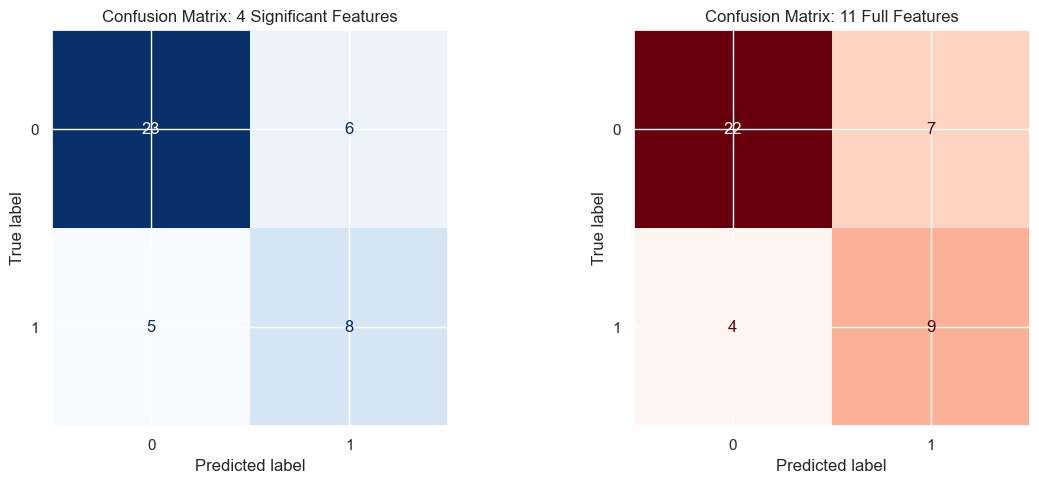

In [ ]:
# Only classification metrics are needed here (mean_absolute_error/r2_score etc.
# don't apply -- DEATH_EVENT is a classification target, not a regression target)
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

# === 1. Evaluate the 4-Feature Polynomial Pipeline ===
print("=== Polynomial Pipeline (4 Significant Features) ===")
# Predict classes (0 or 1) and probabilities (for ROC-AUC)
y_val_pred_sig = best_poly_sig.predict(X_val_sig)
y_val_proba_sig = best_poly_sig.predict_proba(X_val_sig)[:, 1]

print(classification_report(y_val, y_val_pred_sig))

# === 2. Evaluate the 11-Feature Polynomial Pipeline ===
print("=== Polynomial Pipeline (11 Full Features) ===")
y_val_pred_full = best_poly_full.predict(X_val)
y_val_proba_full = best_poly_full.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_val_pred_full))

# === 3. Plot Confusion Matrices Side-by-Side ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    best_poly_sig, X_val_sig, y_val, 
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Confusion Matrix: 4 Significant Features')

ConfusionMatrixDisplay.from_estimator(
    best_poly_full, X_val, y_val, 
    cmap='Reds', ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix: 11 Full Features')

plt.tight_layout()
plt.show()

## K Nearest Neighbours

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# Define the KNN Pipeline
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('knn', KNeighborsClassifier())
])

# Define the hyperparameter grid
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2] # 1 = Manhattan distance, 2 = Euclidean distance
}

# --- Significant features (4) ---
grid_knn_sig = GridSearchCV(knn_pipeline, param_grid_knn, cv=5, scoring='recall', n_jobs=-1)
grid_knn_sig.fit(X_train_sig, y_train)

print("=== KNN (4 significant features) ===")
print(f"Best params: {grid_knn_sig.best_params_}")
print(f"Best Recall (CV): {grid_knn_sig.best_score_:.4f}")
best_knn_sig = grid_knn_sig.best_estimator_

# --- Full features (11) ---
grid_knn_full = GridSearchCV(knn_pipeline, param_grid_knn, cv=5, scoring='recall', n_jobs=-1)
grid_knn_full.fit(X_train, y_train)

print("\n=== KNN (11 full features) ===")
print(f"Best params: {grid_knn_full.best_params_}")
print(f"Best Recall (CV): {grid_knn_full.best_score_:.4f}")
best_knn_full = grid_knn_full.best_estimator_

=== KNN (4 significant features) ===
Best params: {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'uniform'}
Best Recall (CV): 0.4455

=== KNN (11 full features) ===
Best params: {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'uniform'}
Best Recall (CV): 0.2436


=== KNN Validation Evaluation (4 Significant Features) ===
              precision    recall  f1-score   support

           0       0.74      0.90      0.81        29
           1       0.57      0.31      0.40        13

    accuracy                           0.71        42
   macro avg       0.66      0.60      0.61        42
weighted avg       0.69      0.71      0.68        42

=== KNN Validation Evaluation (11 Full Features) ===
              precision    recall  f1-score   support

           0       0.76      0.90      0.83        29
           1       0.62      0.38      0.48        13

    accuracy                           0.74        42
   macro avg       0.69      0.64      0.65        42
weighted avg       0.72      0.74      0.72        42



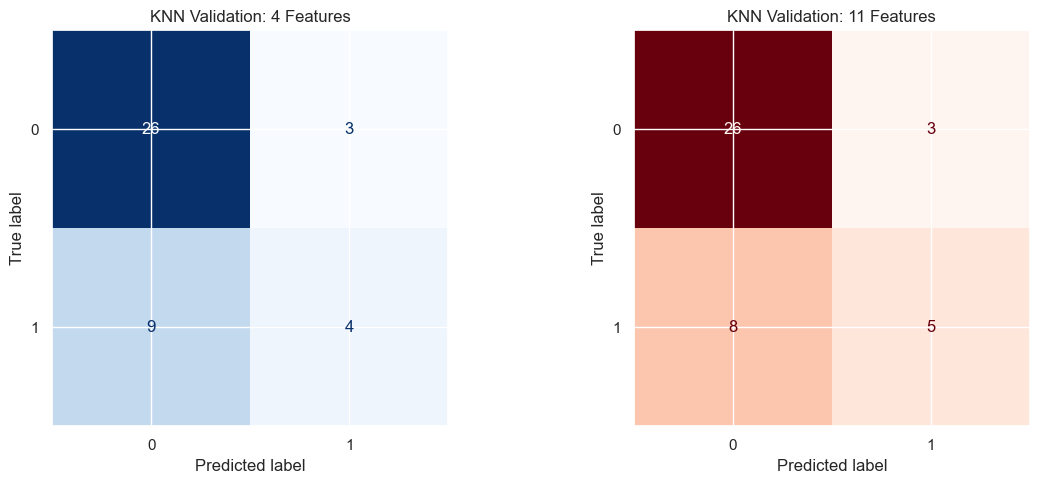

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# === 1. Evaluate KNN on 4 Significant Features ===
print("=== KNN Validation Evaluation (4 Significant Features) ===")
y_val_pred_knn_sig = best_knn_sig.predict(X_val_sig)
print(classification_report(y_val, y_val_pred_knn_sig))

# === 2. Evaluate KNN on 11 Full Features ===
print("=== KNN Validation Evaluation (11 Full Features) ===")
y_val_pred_knn_full = best_knn_full.predict(X_val)
print(classification_report(y_val, y_val_pred_knn_full))

# === 3. Plot Confusion Matrices Side-by-Side ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    best_knn_sig, X_val_sig, y_val, 
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('KNN Validation: 4 Features')

ConfusionMatrixDisplay.from_estimator(
    best_knn_full, X_val, y_val, 
    cmap='Reds', ax=axes[1], colorbar=False
)
axes[1].set_title('KNN Validation: 11 Features')

plt.tight_layout()
plt.show()

## Support Vector Classifiers

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(class_weight='balanced', probability=True, random_state=42))
])

# Dropped C=0.01 — it was producing degenerate, everyone-class-0 models.
# Extended the upper end since low C was clearly too weak here.
param_grid_svc = [
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.1, 1, 10, 100, 1000]
    },
    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.1, 1, 10, 100, 1000],
        'svc__gamma': ['scale', 'auto']
    },
    {
        'svc__kernel': ['poly'],
        'svc__C': [0.1, 1, 10, 100, 1000],
        'svc__gamma': ['scale', 'auto'],
        'svc__degree': [2, 3, 4]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def run_svc_search(X_tr, y_tr, X_v, y_v, label):
    # scoring='f1' instead of 'recall' — recall alone let a collapsed,
    # predict-everyone-0 model look artificially good on noisy folds.
    grid = GridSearchCV(svc_pipeline, param_grid_svc, cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_tr, y_tr)

    print(f"=== Support Vector Classifier ({label}) ===")
    print(f"Best params: {grid.best_params_}")
    print(f"Best F1 (CV): {grid.best_score_:.4f}")

    # Inspect the top of the grid, not just the single winner —
    # a high std_test_score means that result is unstable across folds
    # and shouldn't be trusted just because it ranked #1.
    results = pd.DataFrame(grid.cv_results_)
    results_sorted = results.sort_values('mean_test_score', ascending=False)
    cols = ['param_svc__kernel', 'param_svc__C', 'param_svc__gamma',
            'param_svc__degree', 'mean_test_score', 'std_test_score']
    print("\nTop 10 param combos by CV F1:")
    print(results_sorted[cols].head(10).to_string(index=False))

    y_pred = grid.best_estimator_.predict(X_v)
    print("\nValidation set classification report:")
    print(classification_report(y_v, y_pred, zero_division=0))
    print()

    return grid.best_estimator_


# --- Significant features (4) ---
best_svc_sig = run_svc_search(X_train_sig, y_train, X_val_sig, y_val, "4 significant features")

# --- Full features (11) ---
best_svc_full = run_svc_search(X_train, y_train, X_val, y_val, "11 full features")

=== Support Vector Classifier (4 significant features) ===
Best params: {'svc__C': 10, 'svc__kernel': 'linear'}
Best F1 (CV): 0.6785

Top 10 param combos by CV F1:
param_svc__kernel  param_svc__C param_svc__gamma  param_svc__degree  mean_test_score  std_test_score
           linear          10.0              NaN                NaN         0.678499        0.087937
           linear           1.0              NaN                NaN         0.671130        0.084204
           linear         100.0              NaN                NaN         0.668499        0.075518
           linear        1000.0              NaN                NaN         0.668499        0.075518
           linear           0.1              NaN                NaN         0.657692        0.099644
              rbf           0.1            scale                NaN         0.639716        0.090114
              rbf           0.1             auto                NaN         0.639716        0.090114
             poly         10

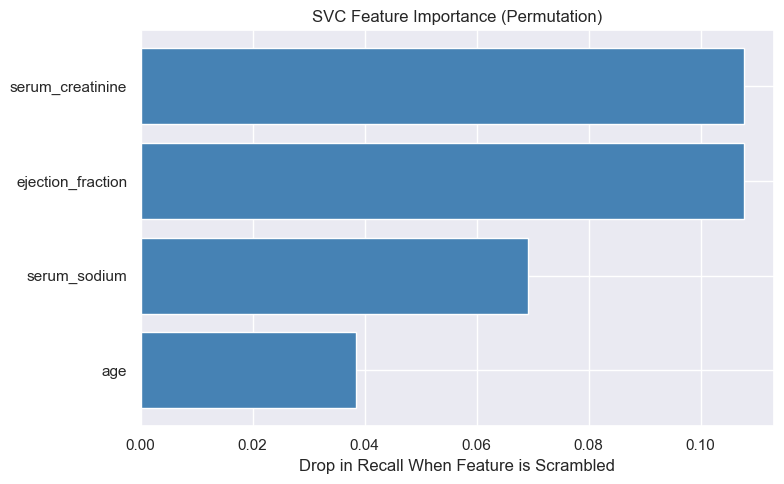

In [ ]:
from sklearn.inspection import permutation_importance

# Execute permutation importance on the unseen validation set
result = permutation_importance(
    best_svc_sig, X_val_sig, y_val, 
    n_repeats=10, random_state=42, n_jobs=-1, scoring='recall'
)

# Sort features by their importance mean
sorted_idx = result.importances_mean.argsort()
features = np.array(X_val_sig.columns)[sorted_idx]
importances = result.importances_mean[sorted_idx]

# Plot the results
plt.figure(figsize=(8, 5))
plt.barh(features, importances, color='steelblue')
plt.xlabel("Drop in Recall When Feature is Scrambled")
plt.title("SVC Feature Importance (Permutation)")
plt.tight_layout()
plt.show()

## Models Evaluation


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

# --- Collect predictions on the TEST set for every fitted model ---
# (These variables assume best_log_sig, best_log_full, best_poly_sig, best_poly_full,
#  best_knn_sig, best_knn_full, best_svc_sig, best_svc_full already exist from earlier cells)

test_sets = {
    'Logistic Regression (4 sig)':   (best_log_sig,  X_test_sig_scaled),
    'Logistic Regression (11 full)': (best_log_full, X_test_full_scaled),
    'Polynomial LogReg (4 sig)':     (best_poly_sig,  X_test_sig),
    'Polynomial LogReg (11 full)':   (best_poly_full, X_test),
    'KNN (4 sig)':                   (best_knn_sig,  X_test_sig),
    'KNN (11 full)':                 (best_knn_full, X_test),
    'SVC (4 sig)':                   (best_svc_sig,  X_test_sig),
    'SVC (11 full)':                 (best_svc_full, X_test),
}

results_summary = []

for name, (model, X_te) in test_sets.items():
    y_pred = model.predict(X_te)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # ROC-AUC needs probabilities, not just class labels
    try:
        y_proba = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    except AttributeError:
        auc = None

    results_summary.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Precision (class 1)': report['1']['precision'],
        'Recall (class 1)': report['1']['recall'],
        'F1 (class 1)': report['1']['f1-score'],
        'ROC-AUC': auc
    })

    print(f"=== {name} — TEST SET ===")
    print(classification_report(y_test, y_pred, zero_division=0))
    print()

# --- Summary table across all 8 model/feature-set combos ---
summary_df = pd.DataFrame(results_summary).sort_values('Recall (class 1)', ascending=False)
print("=== Test Set Performance Summary (sorted by Recall) ===")
print(summary_df.to_string(index=False))

=== Logistic Regression (4 sig) — TEST SET ===
              precision    recall  f1-score   support

           0       0.86      0.72      0.79        61
           1       0.56      0.76      0.65        29

    accuracy                           0.73        90
   macro avg       0.71      0.74      0.72        90
weighted avg       0.77      0.73      0.74        90


=== Logistic Regression (11 full) — TEST SET ===
              precision    recall  f1-score   support

           0       0.82      0.77      0.80        61
           1       0.58      0.66      0.61        29

    accuracy                           0.73        90
   macro avg       0.70      0.71      0.70        90
weighted avg       0.74      0.73      0.74        90


=== Polynomial LogReg (4 sig) — TEST SET ===
              precision    recall  f1-score   support

           0       0.84      0.70      0.77        61
           1       0.54      0.72      0.62        29

    accuracy                           

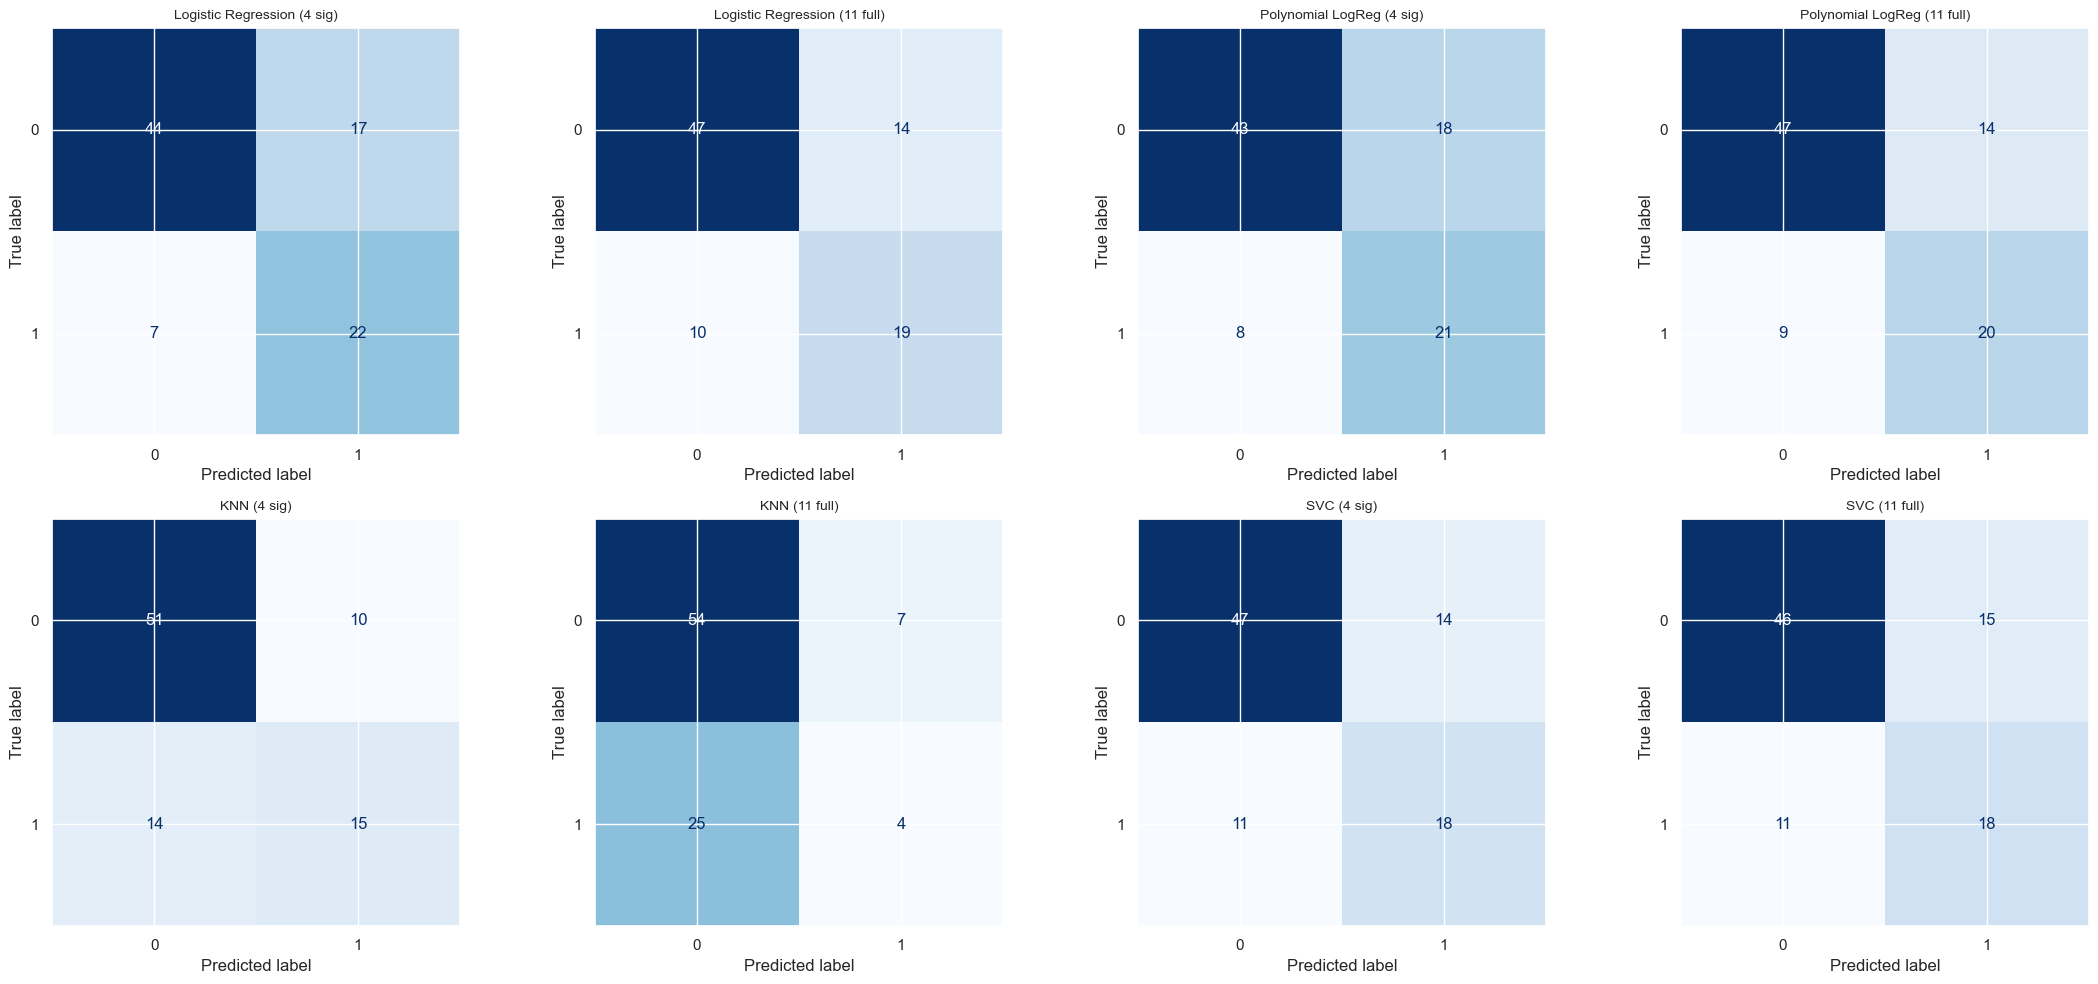

In [ ]:
# --- Confusion matrices for every model, side by side ---
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for ax, (name, (model, X_te)) in zip(axes, test_sets.items()):
    y_pred = model.predict(X_te)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()

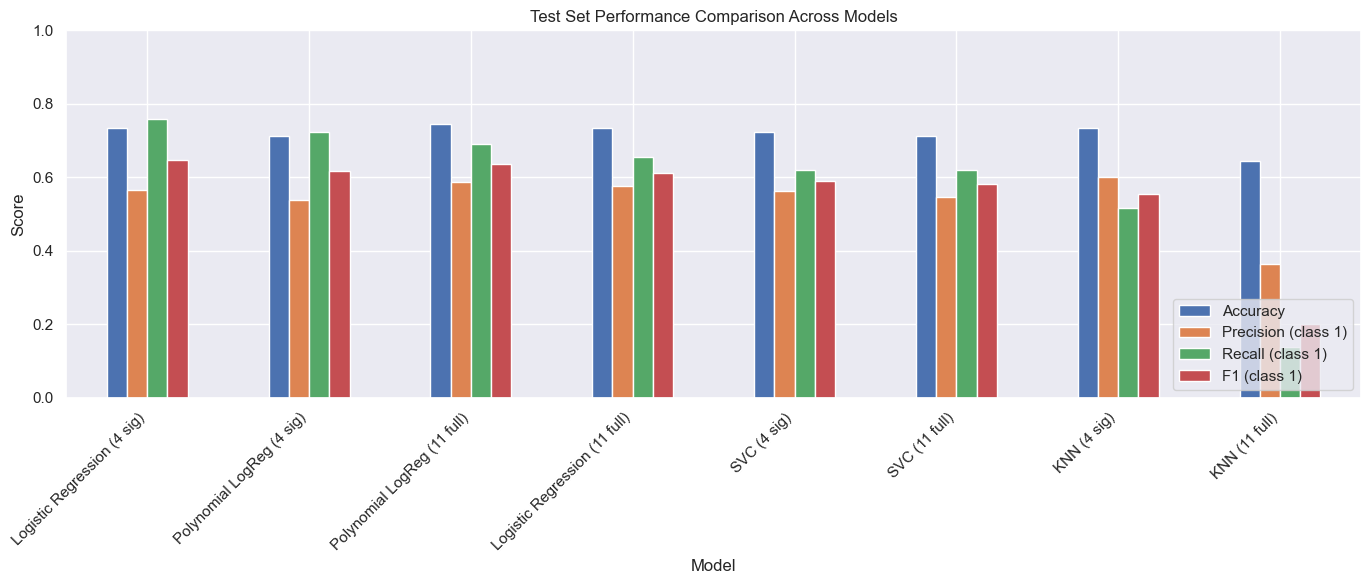

In [ ]:
# --- Bar chart comparing key metrics across all models ---
metrics_to_plot = ['Accuracy', 'Precision (class 1)', 'Recall (class 1)', 'F1 (class 1)']

fig, ax = plt.subplots(figsize=(14, 6))
summary_df.set_index('Model')[metrics_to_plot].plot(kind='bar', ax=ax)
ax.set_title('Test Set Performance Comparison Across Models')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Kaplan-Meier Survival Analysis

In [ ]:
# lifelines is not preinstalled -- install into the SAME environment the notebook
# kernel is using (avoids the common issue of `pip install` targeting a different
# Python than the kernel, which silently fails to make the package importable)
import sys
!{sys.executable} -m pip install lifelines --quiet

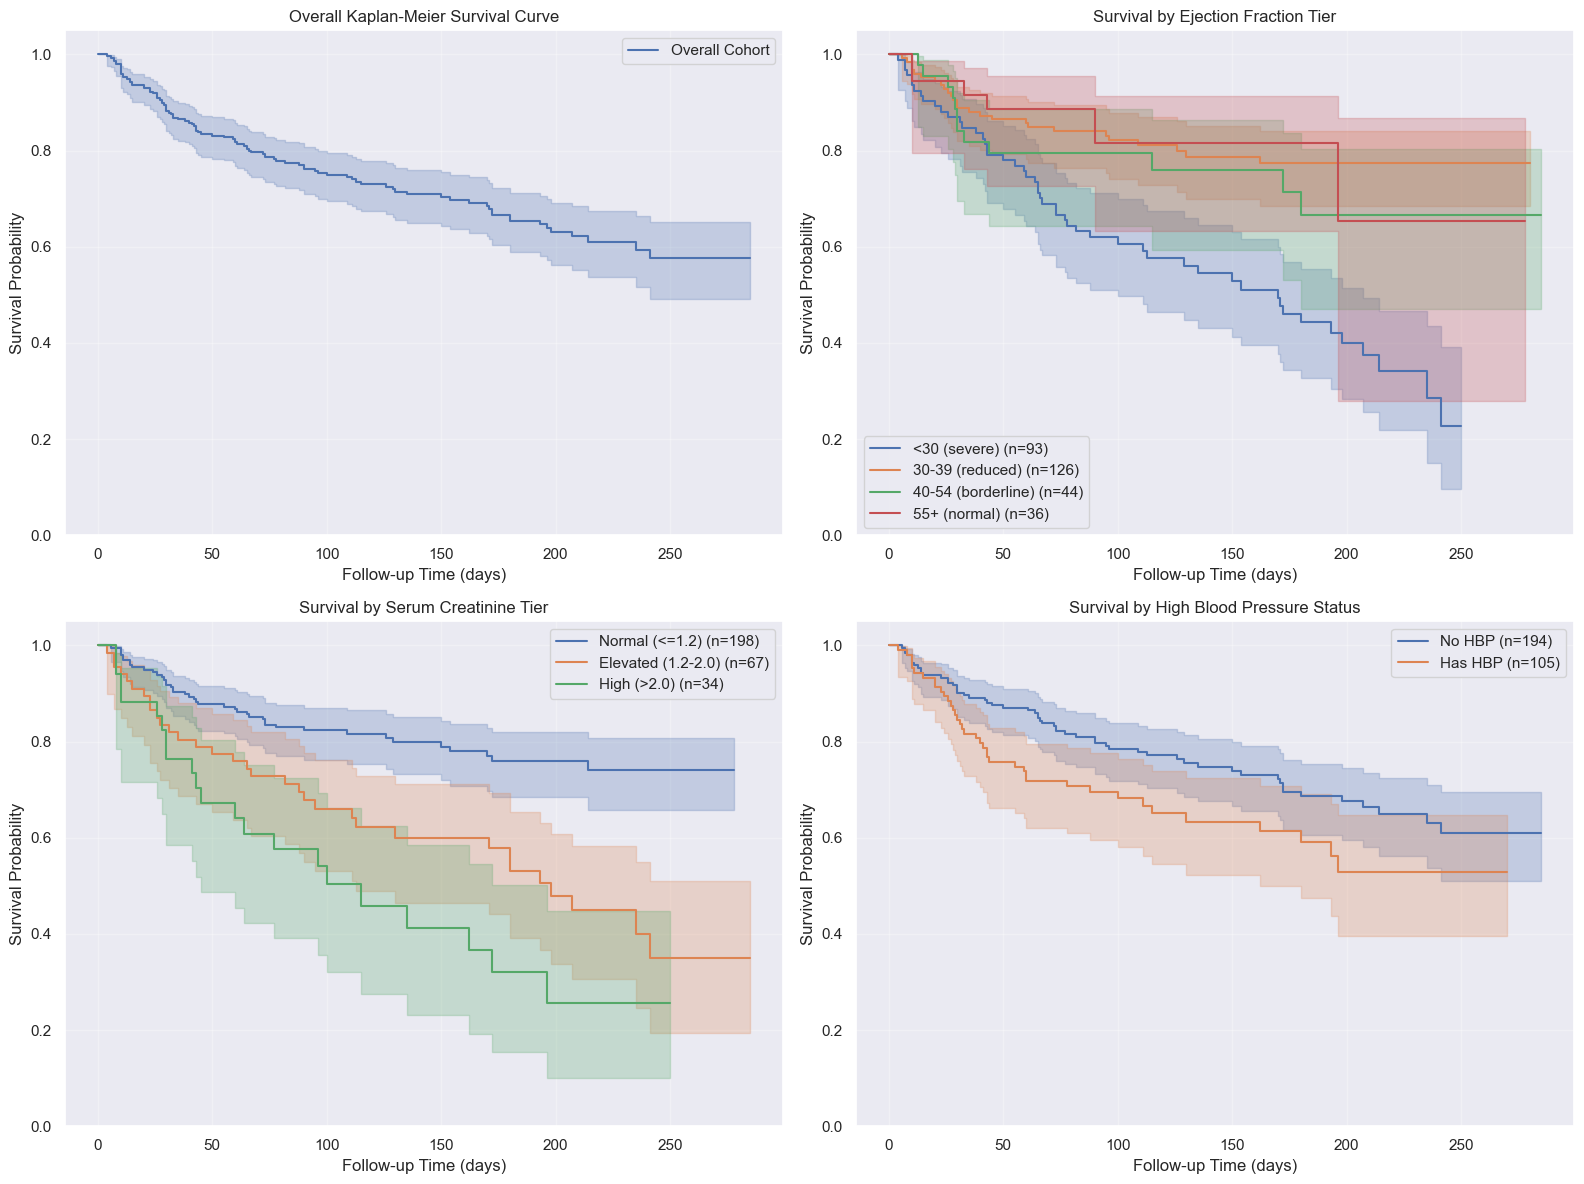

Log-rank test p-value (HBP vs no HBP): 0.0358


In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Panel 1: Overall cohort ---
kmf = KaplanMeierFitter()
kmf.fit(durations=df['time'], event_observed=df['DEATH_EVENT'], label='Overall Cohort')
kmf.plot_survival_function(ax=axes[0, 0])
axes[0, 0].set_title('Overall Kaplan-Meier Survival Curve')
axes[0, 0].set_xlabel('Follow-up Time (days)')
axes[0, 0].set_ylabel('Survival Probability')
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].grid(alpha=0.3)

# --- Panel 2: By ejection fraction tier ---
for tier in df['ef_tier'].cat.categories:
    mask = df['ef_tier'] == tier
    if mask.sum() == 0:
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(durations=df.loc[mask, 'time'], event_observed=df.loc[mask, 'DEATH_EVENT'],
            label=f'{tier} (n={mask.sum()})')
    kmf.plot_survival_function(ax=axes[0, 1])
axes[0, 1].set_title('Survival by Ejection Fraction Tier')
axes[0, 1].set_xlabel('Follow-up Time (days)')
axes[0, 1].set_ylabel('Survival Probability')
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].grid(alpha=0.3)

# --- Panel 3: By serum creatinine tier ---
for tier in df['creatinine_tier'].cat.categories:
    mask = df['creatinine_tier'] == tier
    if mask.sum() == 0:
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(durations=df.loc[mask, 'time'], event_observed=df.loc[mask, 'DEATH_EVENT'],
            label=f'{tier} (n={mask.sum()})')
    kmf.plot_survival_function(ax=axes[1, 0])
axes[1, 0].set_title('Survival by Serum Creatinine Tier')
axes[1, 0].set_xlabel('Follow-up Time (days)')
axes[1, 0].set_ylabel('Survival Probability')
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].grid(alpha=0.3)

# --- Panel 4: By high blood pressure status ---
for status, label in [(0, 'No HBP'), (1, 'Has HBP')]:
    mask = df['high_blood_pressure'] == status
    kmf = KaplanMeierFitter()
    kmf.fit(durations=df.loc[mask, 'time'], event_observed=df.loc[mask, 'DEATH_EVENT'],
            label=f'{label} (n={mask.sum()})')
    kmf.plot_survival_function(ax=axes[1, 1])
axes[1, 1].set_title('Survival by High Blood Pressure Status')
axes[1, 1].set_xlabel('Follow-up Time (days)')
axes[1, 1].set_ylabel('Survival Probability')
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Log-rank test for the HBP comparison (kept separate — it's a stat, not a plot) ---
group_hbp = df[df['high_blood_pressure'] == 1]
group_no_hbp = df[df['high_blood_pressure'] == 0]
result = logrank_test(
    group_hbp['time'], group_no_hbp['time'],
    event_observed_A=group_hbp['DEATH_EVENT'], event_observed_B=group_no_hbp['DEATH_EVENT']
)
print(f"Log-rank test p-value (HBP vs no HBP): {result.p_value:.4f}")

In [ ]:
import joblib

# Save the winning model: Logistic Regression, 4 significant features
# Recall this model was trained on manually pre-scaled data (X_train_sig_scaled),
# so the scaler must be saved and shipped alongside it — the Streamlit app
# needs to apply the exact same transformation to new patient input.

joblib.dump(best_log_sig, 'heart_failure_model.pkl')
joblib.dump(scaler_sig, 'heart_failure_scaler.pkl')

# Save the feature order too — critical, since the scaler/model expect
# columns in this exact order, and it's easy to mix this up later
feature_order = ['serum_creatinine', 'ejection_fraction', 'age', 'serum_sodium']
joblib.dump(feature_order, 'heart_failure_features.pkl')

print("Saved: heart_failure_model.pkl, heart_failure_scaler.pkl, heart_failure_features.pkl")

Saved: heart_failure_model.pkl, heart_failure_scaler.pkl, heart_failure_features.pkl
